# 03 — Evaluación del sistema GraphRAG (metodología RAGAS)

Este notebook evalúa el pipeline usando las tres métricas **RAGAS** descritas en
clase. El enfoque **no** requiere la librería RAGAS —
todas las métricas se implementan como llamadas estructuradas al LLM.

### Las tres métricas

| Métrica | Qué mide | Cómo |
|---|---|---|
| **context_recall** | ¿El recuperador obtuvo chunks que cubren la verdad esperada? | Cada frase del ground truth se verifica: ¿puede atribuirse al contexto recuperado? |
| **faithfulness** | ¿La respuesta contiene solo cosas respaldadas por el contexto? | La respuesta se descompone en afirmaciones atómicas; cada una se verifica contra el contexto. |
| **answer_correctness** | ¿Cuánto se superpone la respuesta con el ground truth? | Las afirmaciones se clasifican en TP / FP / FN; se calcula el F1. |

### El pipeline de evaluación

```
CSV de benchmark
  (question ; cypher)
        │
        ▼
  load_dataset()       ← lee el CSV, ejecuta Cypher para obtener ground truths dinámicos
        │
        ▼
  run_benchmark()      ← llama al agente RAG para cada pregunta, registra la latencia
        │
        ▼
  evaluate_results()   ← puntúa cada fila con las tres métricas RAGAS
        │
        ▼
  print_summary()      ← tabla agregada
```

**Requisito previo:** Ejecutar `01_ingestion_demo.ipynb` para cargar los datos de Einstein en Neo4j.

## 1. Configuración

In [1]:
import sys
sys.path.append('..')
from dotenv import load_dotenv
load_dotenv("../env/.env")

import pandas as pd
from graphrag.graph.neo4j_manager import Neo4jManager
from graphrag.agents import AgenticRAG
from graphrag.evaluation import RAGEvaluator

pd.set_option('display.max_colwidth', 60)
pd.set_option('display.float_format', '{:.3f}'.format)

/home/Pablo/Universidad/02-segundo-cuatrimestre/IAC/GraphRAG-IAC/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
neo4j = Neo4jManager()
rag = AgenticRAG(neo4j)
evaluator = RAGEvaluator(rag, neo4j)
print("Sistema listo.")

Unable to retrieve routing information
Unable to retrieve routing information


Índice vectorial ya existe o error: Unable to retrieve routing information
Índice fulltext ya existe o error: Unable to retrieve routing information


Loading weights: 100%|██████████| 393/393 [00:00<00:00, 15601.80it/s]
Unable to retrieve routing information
Unable to retrieve routing information
Unable to retrieve routing information
Unable to retrieve routing information
Unable to retrieve routing information


Índice vectorial ya existe o error: Unable to retrieve routing information
Added text2cypher examples to the text2cypher retriever.
Added terminology maps to the text2cypher retriever.
Sistema listo.


## 2. Inspección de métricas — pregunta a pregunta

Antes de ejecutar el benchmark completo, es instructivo ver qué hace cada métrica
internamente. Tomamos una sola pregunta y llamamos a cada métrica de forma manual.

In [ ]:
question     = "What is the evolutionary history of the axolotl?"
ground_truth = "Animal: Axolotl\n" \
"Section: Evolution\n" \
"From an evolutionary perspective, axolotls are comparatively extremely young in contrast to other Mexican salamanders. Scientists estimate that they have only been in their native habitat for about 10,000 years. These creatures did not have long to flourish, for around the thirteenth century their home began to be settled by humans. After the land was claimed by Spain in the 1500’s urbanization began to rapidize until the area became modern day Mexico City, leaving but a tiny fraction of the axolotl’s biome for them to dwell.\n" \
"Animal: Axolotl\n" \
"Section: Evolution\n" \
"Biologists have taken note of how axolotls express traits in adulthood that other amphibians only show during adolesence, like breathing underwater, and hypothesize that this could be because of their incredibly brief chance to evolve before their populations became seriously threatened."



# Preguntamos al agente
answer, context = evaluator.get_answer(question)
print(f"Respuesta       : {answer}")
print(f"Chunks recuperados: {len(context)}")

Respuesta       : From an evolutionary perspective, axolotls are comparatively extremely young, estimated to have been in their native habitat for only about 10,000 years [1]. Biologists hypothesize that their expression of adult traits, like breathing underwater, which are typically seen in adolescent amphibians, could be due to their brief evolutionary period before populations became threatened [2].
Chunks recuperados: 5


In [ ]:
# --- context_recall ---
# Objetivo: ¿puede atribuirse cada frase del ground truth al contexto recuperado?
# Puntuación = (frases atribuidas) / (total de frases)  →  rango [0, 1]
recall_result = evaluator.evaluate_context_recall(question, ground_truth, context, verbose=True)

print("context_recall")
print(f"  puntuación : {recall_result.get('recall', 0):.3f}")
print(f"  frases     : {recall_result.get('sentences', [])}")
print(f"  atribuidas : {recall_result.get('attributions', [])}")
print(f"  razonamiento: {recall_result.get('reasoning', '')}")


── context_recall ──────────────────────────────────
  Question    : What is the evolutionary history of the axolotl?
  Ground truth: Animal: Axolotl
Section: Evolution
From an evolutionary perspective, axolotls are comparatively extremely young in contrast to other Mexican salamanders. Scientists estimate that they have only been in their native habitat for about 10,000 years. These creatures did not have long to flourish, for around the thirteenth century their home began to be settled by humans. After the land was claimed by Spain in the 1500’s urbanization began to rapidize until the area became modern day Mexico City, leaving but a tiny fraction of the axolotl’s biome for them to dwell.
Animal: Axolotl
Section: Evolution
Biologists have taken note of how axolotls express traits in adulthood that other amphibians only show during adolesence, like breathing underwater, and hypothesize that this could be because of their incredibly brief chance to evolve before their populations bec

In [ ]:
# --- faithfulness ---
# Paso 1: descomponer la respuesta en afirmaciones atómicas sin pronombres.
# Paso 2: verificar si cada afirmación puede inferirse del contexto.
# Puntuación = (afirmaciones respaldadas) / (total)  →  rango [0, 1]
faith_result = evaluator.evaluate_faithfulness(question, answer, context, verbose=True)

print("faithfulness")
print(f"  puntuación  : {faith_result.get('faithfulness', 0):.3f}")
print(f"  afirmaciones: {faith_result.get('statements', [])}")
print(f"  veredictos  : {faith_result.get('verdicts', [])}")


── faithfulness ────────────────────────────────────
  Question: What is the evolutionary history of the axolotl?
  Answer  : From an evolutionary perspective, axolotls are comparatively extremely young, estimated to have been in their native habitat for only about 10,000 years [1]. Biologists hypothesize that their expression of adult traits, like breathing underwater, which are typically seen in adolescent amphibians, could be due to their brief evolutionary period before populations became threatened [2].

  [Step 1] Decomposing the answer into statements...
  Statements extracted (4):
    1. From an evolutionary perspective, axolotls are comparatively extremely young.
    2. Axolotls are estimated to have been in their native habitat for only about 10,000 years.
    3. Biologists hypothesize that the axolotl's expression of adult traits, like breathing underwater, could be due to their brief evolutionary period before populations became threatened.
    4. Breathing underwater is a

In [ ]:
# --- answer_correctness ---
# Se descomponen tanto la respuesta como el ground truth en afirmaciones.
# Cada afirmación se clasifica en TP / FP / FN.
# Puntuación = F1(precisión, recall) calculado a partir de los conteos TP / FP / FN.
corr_result = evaluator.evaluate_answer_correctness(question, answer, ground_truth, verbose=True)

print("answer_correctness")
print(f"  F1        : {corr_result.get('answer_correctness', 0):.3f}")
print(f"  precisión : {corr_result.get('precision', 0):.3f}")
print(f"  recall    : {corr_result.get('recall', 0):.3f}")
print(f"  TP={corr_result.get('tp',0)}  FP={corr_result.get('fp',0)}  FN={corr_result.get('fn',0)}")


── answer_correctness ──────────────────────────────
  Question    : What is the evolutionary history of the axolotl?
  Answer      : From an evolutionary perspective, axolotls are comparatively extremely young, estimated to have been in their native habitat for only about 10,000 years [1]. Biologists hypothesize that their expression of adult traits, like breathing underwater, which are typically seen in adolescent amphibians, could be due to their brief evolutionary period before populations became threatened [2].
  Ground truth: Animal: Axolotl
Section: Evolution
From an evolutionary perspective, axolotls are comparatively extremely young in contrast to other Mexican salamanders. Scientists estimate that they have only been in their native habitat for about 10,000 years. These creatures did not have long to flourish, for around the thirteenth century their home began to be settled by humans. After the land was claimed by Spain in the 1500’s urbanization began to rapidize until the 

## 3. Pipeline de benchmark completo

### Formato del dataset de benchmark

El benchmark es un CSV delimitado por punto y coma con dos columnas:
- `question` — la pregunta en lenguaje natural
- `cypher` — una consulta Cypher que se **ejecuta en tiempo de ejecución** para obtener el ground truth

Este diseño garantiza que los ground truths estén siempre sincronizados con el estado
real del grafo: no hay cadenas de texto codificadas que queden desactualizadas al cambiar los datos.

### Categorías de preguntas

| Categoría | Ejemplos | Propósito |
|---|---|---|
| **Saludos** | "Hello", "What can you do?" | Evaluar respuesta conversacional |
| **Fuera de ámbito** | "Weather?", "World Cup?" | Evaluar rechazo correcto |
| **Datos ausentes** | "Einstein's middle name?" | Evaluar honestidad del sistema |
| **Hechos simples** | "Where was Einstein born?" | Evaluar recuperación directa |
| **Consultas relacionales** | "Which institutions did Einstein work at?" | Evaluar traversal de grafo |
| **Consultas complejas** | "Where did Einstein live after Germany?" | Evaluar razonamiento multi-salto |
| **Agregaciones** | "How many Person nodes?" | Evaluar text2cypher |

El dataset inline cubre 20 preguntas; el CSV en `../data/benchmark_data.csv` cubre 38 preguntas.

> **⚠️ Requisito previo — datos del grafo**
>
> Las consultas Cypher de este benchmark usan el esquema de dominio nuevo
> (`Person`, `Location`, `ScientificTheory`, `Institution`, `Award`, `ScientificField`).
> Si el grafo todavía contiene nodos del esquema genérico antiguo (`Entity {type}`),
> las consultas devolverán resultados vacíos.
>
> Para reiniciar desde cero, ejecuta las dos celdas siguientes y luego vuelve a correr
> `01_ingestion_demo.ipynb` antes de continuar.

```python
# Vaciar la base de datos (¡irreversible!)
# neo4j.execute_query('MATCH (n) DETACH DELETE n')
# print('Base de datos vaciada — ejecuta 01_ingestion_demo.ipynb antes de continuar.')
```

In [ ]:
DATASET_PATH = "../data/benchmark_data.csv"

dataset = pd.read_csv(DATASET_PATH, delimiter=";")
print(f"Dataset de benchmark: {len(dataset)} preguntas")
dataset.head(10)

Dataset de benchmark: 50 preguntas


,question,cypher,tool
0,Hello!,RETURN 'Hoot hoot! 🦉 I am a highly intellectual knowledg...,greeting
1,What can you do?,"RETURN 'With my eight arms and three brains, I can juggl...",skills
2,What is the weather like today?,"RETURN 'Umm... moo? 🐄 Sorry, this question is way outsid...",out_of_scope
3,Good morning,RETURN 'Hoot hoot! 🦉 I am a highly intellectual knowledg...,greeting
4,What kind of questions can I ask you?,"RETURN 'With my eight arms and three brains, I can juggl...",skills
5,Can you give me a recipe for paella?,"RETURN 'Umm... moo? 🐄 Sorry, this question is way outsid...",out_of_scope
6,What does the african elephant eat?,MATCH (s:Species {name: 'Elephant'}) OPTIONAL MATCH (s)-...,text2cypher
7,Where does the emperor penguin live?,MATCH (s:Species {name: 'Penguin'}) OPTIONAL MATCH (s)-[...,text2cypher
8,Is the Earthworm a vertebrate or invertebrate?,MATCH (s:Species {name: 'Earthworm'})-[:HAS_SKELETAL_STR...,text2cypher
9,Is the Cat a vertebrate or invertebrate?,RETURN 'This information is not in the knowledge base.' ...,text2cypher


### 3.1 `run_benchmark()` — ejecutar ground truths Cypher y llamar al agente

Para cada fila:
1. Ejecuta la consulta Cypher → string con el ground truth
2. Llama a `rag.answer(question)` → respuesta del agente + contextos recuperados
3. Registra la latencia en segundos

In [ ]:
results_df = evaluator.run_benchmark(dataset, verbose=True)

print(f"\nBenchmark completo — {len(results_df)} filas")
results_df[['question', 'ground_truth', 'answer', 'latency']]

Resuming benchmark from row 45...


Processing rows:   0%|          | 0/50 [00:00<?, ?it/s]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  [45/50] Describe the diet of the animals that weigh more than 50 kilograms
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  [Step 1] Executing Cypher ground truth...
           MATCH (c:Chunk) WHERE c.id IN ['gorilla_chunk_11', 'tiger_chunk_13', 'cow_chunk_25', 'elephant_chunk_19', 'killer_whale_chunk_18', 'sea_turtle_chunk_14', 'octopus_chunk_21', 'kangaroo_chunk_17', 'rhinoceros_chunk_17', 'polar_bear_chunk_16'] RETURN coalesce(c.text, 'This information is not in the knowledge base.') AS ground_truth
  Ground truth: Animal: Gorilla
Section: Diet
Most of these animals are vegetarian, but the western lowland gorilla also eats insects .; Animal: Tiger
Section: Diet
What does a tiger eat? With powerful jaws, claws, and superb hunting abilities -tigers are carnivores who eat pretty much anything they want. Deer , antelope , buffalo , and pigs are some of the prey of tigers. Tigers have even been known to eat leo

Processing rows:  90%|█████████ | 45/50 [01:28<00:09,  1.96s/it]

  Answer  : The Tiger is a carnivore that eats deer, antelope, buffalo, pigs, leopards, and crocodiles [2]. The Elephant eats grasses, leaves, fruits, twigs, roots, and bark [5]. The Sea Turtle has a diverse diet that varies by species, location, and age [7]. The Killer Whale (Orca) has a carnivorous diet, with prey depending on whether it is a resident, transient, or offshore orca [4]. The Cow is a herbivore that eats grass and other plants [3]. The Polar Bear is a carnivorous mammal that eats ringed seals, birds, berries, fish, reindeer, and walrus [9]. The Giant Panda eats bamboo [12]. The Ostrich eats seeds, fruits, and leaves [13]. The Turtle eats algae and seagrass [14]. The Hippopotamus eats grasses and aquatic plants [15]. The Gorilla is mostly vegetarian but also eats insects [6]. The Turtle weighs 2222.6 kg [1]. The Octopus eats crabs, crustaceans, lobsters, and plankton [8]. The Rhinoceros is a herbivore that eats grasses, leaves, shoots, buds, and fruits [10]. The Kangaroo'

...

Processing rows:  98%|█████████▊| 49/50 [04:13<00:09,  9.36s/it]

  Answer  : The African Elephant is hunted by the Jaguar, Lion, Tiger, Hyena, and African Wild Dog [1]. The African Elephant does not hunt any animals [1].
  Context chunks: 1
  Latency : 19.86s
  Used tools: ['predefined_predator_prey_chain']
  Expected tool: predefined_predator_prey_chain

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  [50/50] How are birds socially organized?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  [Step 1] Executing Cypher ground truth...
           MATCH (s:Species)-[:BELONGS_TO_CLASS]->(c:AnimalClass {type: 'Bird'}) MATCH (s)-[:ORGANIZED_IN]->(ss:SocialStructure) RETURN ss.type AS social_structure, count(s) AS species_count ORDER BY species_count DESC
  Ground truth: social_structure: Pair-living, species_count: 8; social_structure: Family group, species_count: 4; social_structure: Colony, species_count: 4; social_structure: Herd, species_count: 3; social_structure: Solitary, species_count: 2; social_structure: Pack, species

Processing rows: 100%|██████████| 50/50 [04:32<00:00,  5.46s/it]

  Answer  : Birds are socially organized in various ways, including pair-living, family groups, colonies, herds, solitary, and packs [1]. There are 8 species that are pair-living, 4 species that live in family groups, 4 species that live in colonies, 3 species that form herds, 2 species that are solitary, and 1 species that lives in a pack [1].
  Context chunks: 1
  Latency : 14.22s
  Used tools: ['predefined_social_structure_by_class']
  Expected tool: predefined_social_structure_by_class


NameError: name 'df' is not defined

### 3.2 `evaluate_results()` — puntuar cada fila con las tres métricas RAGAS

Este paso es el más intensivo en LLM: cada fila hace ~5 llamadas al LLM
(context_recall × 1, faithfulness × 2, answer_correctness × 3).
Esperar unos 10–30 segundos por fila dependiendo del modelo.

In [3]:
results_df = pd.read_csv('benchmark_backup.csv', sep=';', encoding='utf-8')
import ast

# Convertir de string a lista real
results_df['used_tools'] = results_df['used_tools'].apply(ast.literal_eval)
results_df['retrieved_contexts'] = results_df['retrieved_contexts'].apply(ast.literal_eval)

# Ahora puedes, por ejemplo, contar cuántas herramientas se usaron
results_df['num_tools'] = results_df['used_tools'].apply(len)

print(results_df.head(10))
print(results_df.info())

                                         question  \
0                                          Hello!   
1                                What can you do?   
2                 What is the weather like today?   
3                                    Good morning   
4           What kind of questions can I ask you?   
5            Can you give me a recipe for paella?   
6         Who won the football world cup in 2022?   
7             What does the african elephant eat?   
8            Where does the emperor penguin live?   
9  Is the Earthworm a vertebrate or invertebrate?   

                                                        cypher          tool  \
0  RETURN 'Hoot hoot! 🦉 I am a highly intellectual knowledg...      greeting   
1  RETURN 'With my eight arms and three brains, I can juggl...        skills   
2  RETURN 'Umm... moo? 🐄 Sorry, this question is way outsid...  out_of_scope   
3  RETURN 'Hoot hoot! 🦉 I am a highly intellectual knowledg...      greeting   
4  RETURN 'With 

In [6]:
scored_df = evaluator.evaluate_results(results_df, verbose=True)

print(f"\nPuntuación completada.")
scored_df[['question', 'context_recall', 'faithfulness', 'answer_correctness', 'latency', 'is_tool_correct']]

Resuming evaluation from row 24...


Evaluating:   0%|          | 0/49 [00:00<?, ?it/s]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Q: What makes human brains more advanced than dolphin brains?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

── context_recall ──────────────────────────────────
  Question    : What makes human brains more advanced than dolphin brains?
  Ground truth: Animal: Dolphin
Section: Intelligence
Dolphins have brains that are larger than human brains and are among the most intelligent species on Earth . They possess surprisingly complex communication. Yet, they’re not as smart as humans. What are the key differences between human brains and dolphin brains? One difference is that dolphin brains have a relatively small prefrontal cortex and a smaller hippocampus. These smaller areas on the brain lead to dolphins having less higher-level thinking and memory when compared to humans. Yet, dolphins are still perhaps the second most intelligent species on Earth.
  Context chunks retrieved: 5

  [Step 1] Asking the LLM to 

Evaluating:  49%|████▉     | 24/49 [00:32<00:33,  1.36s/it]

  Classifications:
    [TP] Dolphin brains have a relatively small prefrontal cortex. — This statement is semantically equivalent to the first ground truth statement.
    [TP] Dolphin brains have a smaller hippocampus. — This statement is semantically equivalent to the second ground truth statement.
    [TP] The small prefrontal cortex and hippocampus in dolphin brains lead to less higher-level thinking when compared to humans. — This statement is partially supported by the third ground truth statement, specifically regarding higher-level thinking.
    [TP] The small prefrontal cortex and hippocampus in dolphin brains lead to less memory when compared to humans. — This statement is partially supported by the third ground truth statement, specifically regarding memory.

  TP=4  FP=0  FN=0
  Precision=1.000  Recall=1.000  F1=1.000
────────────────────────────────────────────────────

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Q: Describe the behavior of the giant pand

...

Evaluating:  98%|█████████▊| 48/49 [19:29<00:51, 51.73s/it]

  Classifications:
    [TP] The African Elephant is hunted by the Jaguar. — The answer statement is semantically equivalent to the ground truth statement.
    [TP] The African Elephant is hunted by the Lion. — The answer statement is semantically equivalent to the ground truth statement.
    [TP] The African Elephant is hunted by the Tiger. — The answer statement is semantically equivalent to the ground truth statement.
    [TP] The African Elephant is hunted by the Hyena. — The answer statement is semantically equivalent to the ground truth statement.
    [TP] The African Elephant is hunted by the African Wild Dog. — The answer statement is semantically equivalent to the ground truth statement.
    [TP] The African Elephant does not hunt any animals. — The answer statement is semantically equivalent to the ground truth statement.

  TP=6  FP=0  FN=0
  Precision=1.000  Recall=1.000  F1=1.000
────────────────────────────────────────────────────

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Evaluating: 100%|██████████| 49/49 [20:20<00:00, 24.91s/it]

  Classifications:
    [TP] Birds are socially organized in various ways, including pair-living, family groups, colonies, herds, solitary, and packs. — This statement broadly covers the social organization types mentioned in the ground truth, although it lists 'packs' which is not explicitly in the ground truth as a type of social organization for birds.
    [TP] There are 8 species of birds that are pair-living. — This statement directly matches ground truth statement 1.
    [TP] There are 4 species of birds that live in family groups. — This statement directly matches ground truth statement 2.
    [TP] There are 4 species of birds that live in colonies. — This statement directly matches ground truth statement 3.
    [TP] There are 3 species of birds that form herds. — This statement directly matches ground truth statement 4.
    [TP] There are 2 species of birds that are solitary. — This statement directly matches ground truth statement 5.
    [TP] There is 1 species of bird that liv

,question,context_recall,faithfulness,answer_correctness,latency,is_tool_correct
0,Hello!,1.000,1.000,0.933,6.106,True
1,What can you do?,1.000,0.857,1.000,2.898,True
2,What is the weather like today?,1.000,1.000,1.000,1.769,True
3,Good morning,1.000,0.889,0.800,1.899,True
4,What kind of questions can I ask you?,1.000,0.857,0.923,6.137,True
5,Can you give me a recipe for paella?,1.000,1.000,0.800,1.601,True
6,What does the african elephant eat?,1.000,1.000,1.000,29.904,True
7,Where does the emperor penguin live?,0.154,0.222,0.900,62.823,True
8,Is the Earthworm a vertebrate or invertebrate?,1.000,1.000,1.000,22.969,True
9,Is the Cat a vertebrate or invertebrate?,0.000,1.000,0.000,103.692,True


### 3.3 `print_summary()` — resultados agregados

El resumen reproduce la tabla de resumen de benchmark que hemos comentado en clase.
Un sistema bien ajustado debería superar 0.7 en las tres métricas.

In [7]:
evaluator.print_summary(scored_df)


=== Benchmark Summary ===
answer_correctness       : 0.6024
context_recall           : 0.7681
faithfulness             : 0.9118
avg_latency_s            : 37.60


## 4. Análisis de resultados

In [14]:
import pandas as pd

# 1. Leer el archivo
df = pd.read_csv('evaluation_backup.csv', sep=';')

# 2. Cadena de rechazo exacta
rechazo_exacto = "RETURN 'This information is not in the knowledge base.' AS ground_truth"

# 3. Crear el filtro
mask_rechazo = df['cypher'].str.strip() == rechazo_exacto
df_limpio = df[~mask_rechazo]

# 4. Calcular métricas en ambos grupos
metricas_globales = ['latency', 'num_tools', 'faithfulness', 'is_tool_correct']
metricas_rag = ['context_recall', 'answer_correctness']
todas_metricas = metricas_globales + metricas_rag

# Medias sobre TODAS las preguntas
medias_todas = df[todas_metricas].mean()

# Medias sobre preguntas filtradas (sin rechazo)
medias_filtradas = df_limpio[todas_metricas].mean()

# 5. Construir tabla comparativa
comparativa = pd.DataFrame({
    f'Todas ({len(df)} preguntas)': (medias_todas * 100).round(2),
    f'Filtradas ({len(df_limpio)} preguntas)': (medias_filtradas * 100).round(2),
    'Diferencia': ((medias_filtradas - medias_todas) * 100).round(2)
})

# Añadir nota sobre disponibilidad de métricas RAG en el grupo global
comparativa['Nota'] = ''
comparativa.loc[metricas_rag, 'Nota'] = '⚠ incluye rechazos'

print("=" * 70)
print("COMPARATIVA DE MÉTRICAS (en %)")
print("=" * 70)
print(comparativa.to_string())
print()
print("─" * 70)
print("MÉTRICAS GLOBALES (diseñadas para todas las preguntas)")
print("─" * 70)
print((df[metricas_globales].mean() * 100).round(2).to_string())
print()
print("─" * 70)
print(f"MÉTRICAS RAG REAL (solo {len(df_limpio)} preguntas de búsqueda)")
print("─" * 70)
print((df_limpio[metricas_rag].mean() * 100).round(2).to_string())

COMPARATIVA DE MÉTRICAS (en %)
                    Todas (50 preguntas)  Filtradas (45 preguntas)  Diferencia                Nota
latency                         3687.930                  3549.500    -138.430                    
num_tools                        102.000                   102.220       0.220                    
faithfulness                      96.440                    96.040      -0.400                    
is_tool_correct                   88.000                    86.670      -1.330                    
context_recall                    82.580                    87.310       4.730  ⚠ incluye rechazos
answer_correctness                74.000                    80.550       6.560  ⚠ incluye rechazos

──────────────────────────────────────────────────────────────────────
MÉTRICAS GLOBALES (diseñadas para todas las preguntas)
──────────────────────────────────────────────────────────────────────
latency           3687.930
num_tools          102.000
faithfulness        96.4

### 4.1 Distribución por métrica

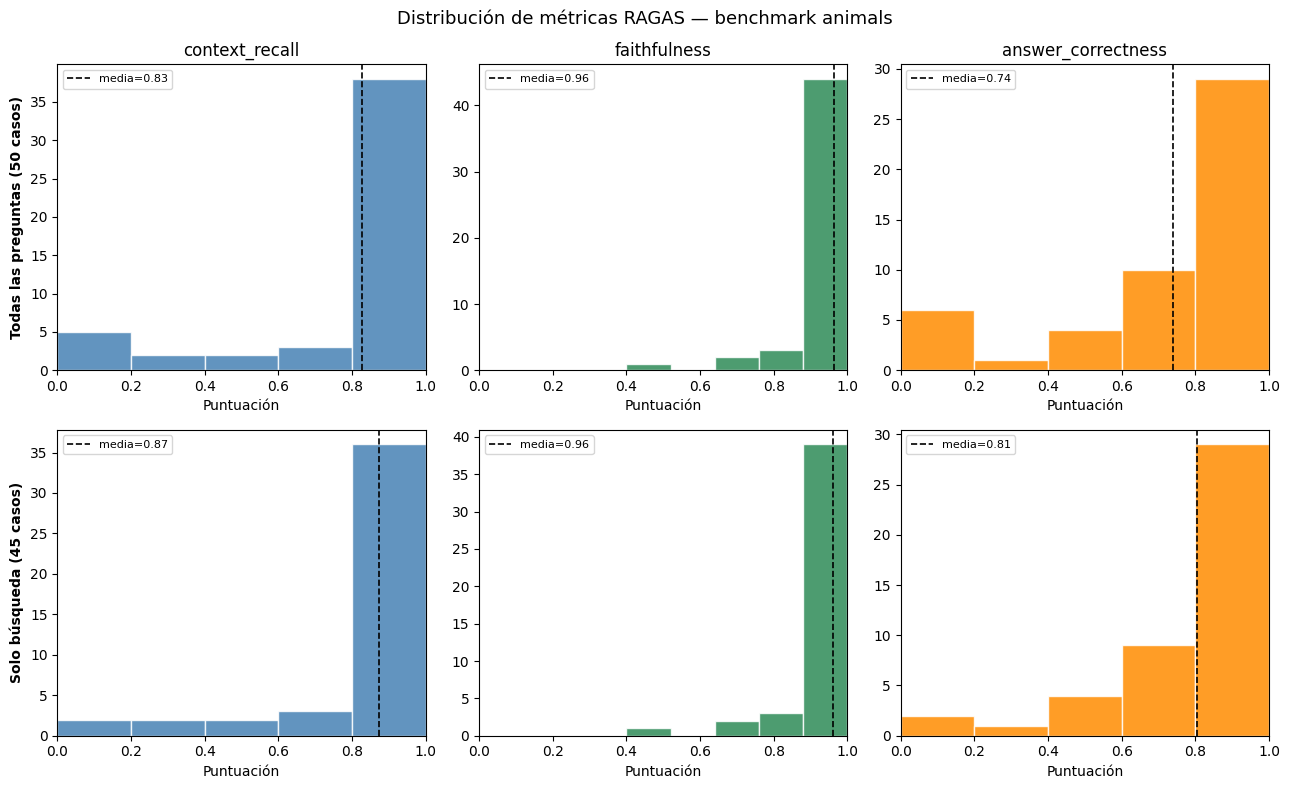

In [20]:
import matplotlib.pyplot as plt

metrics = ['context_recall', 'faithfulness', 'answer_correctness']
colors  = ['steelblue', 'seagreen', 'darkorange']

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
fig.suptitle('Distribución de métricas RAGAS — benchmark animals', fontsize=13)

datasets = [
    (df,        f'Todas las preguntas ({len(df)} casos)'),
    (df_limpio, f'Solo búsqueda ({len(df_limpio)} casos)'),
]

for row, (dataset, titulo) in enumerate(datasets):
    axes[row, 0].set_ylabel(titulo, fontsize=10, fontweight='bold')

    for col, (metric, color) in enumerate(zip(metrics, colors)):
        ax = axes[row, col]
        data = dataset[metric].dropna()
        media = data.mean()

        ax.hist(data, bins=5, color=color, edgecolor='white', alpha=0.85)
        ax.axvline(media, color='black', linestyle='--', linewidth=1.2,
                   label=f'media={media:.2f}')
        ax.set_title(metric if row == 0 else '')
        ax.set_xlabel('Puntuación')
        ax.set_xlim(0, 1)
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

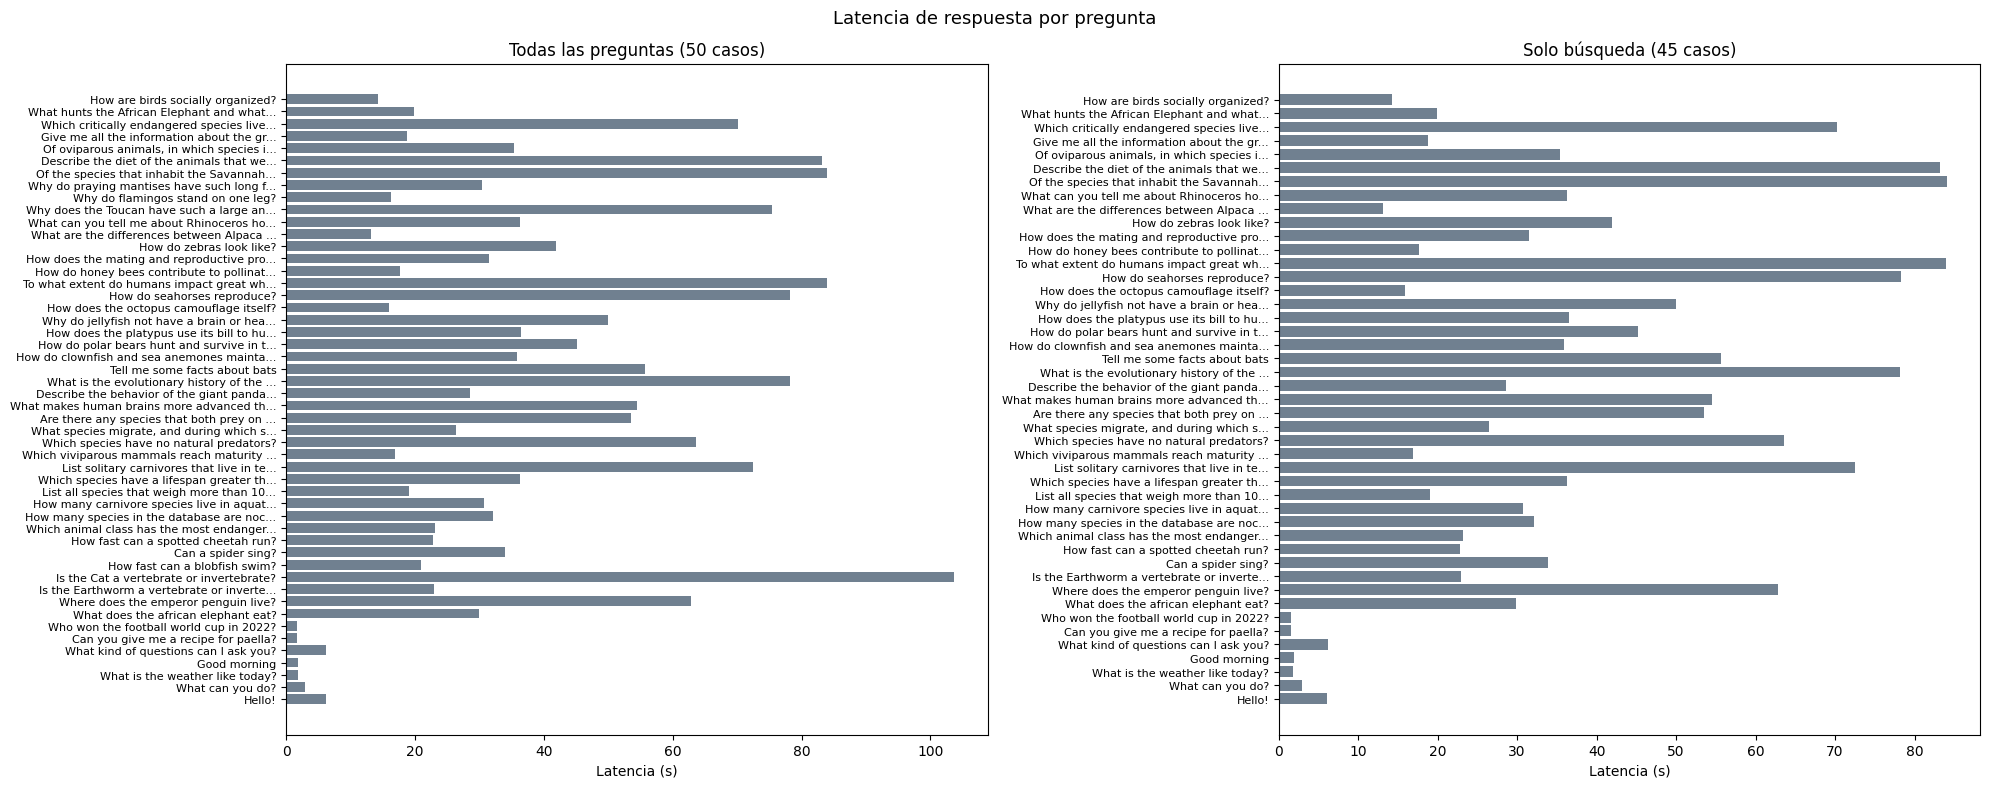

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

datasets = [
    (df,        f'Todas las preguntas ({len(df)} casos)'),
    (df_limpio, f'Solo búsqueda ({len(df_limpio)} casos)'),
]

for ax, (dataset, titulo) in zip(axes, datasets):
    ax.barh(range(len(dataset)), dataset['latency'], color='slategray')
    ax.set_yticks(range(len(dataset)))
    ax.set_yticklabels(
        [q[:40] + '...' if len(q) > 40 else q for q in dataset['question']],
        fontsize=8
    )
    ax.set_xlabel('Latencia (s)')
    ax.set_title(titulo)

plt.suptitle('Latencia de respuesta por pregunta', fontsize=13)
plt.tight_layout()
plt.show()

### 4.2 Mejor y peor caso por answer_correctness

Inspeccionar los extremos ayuda a diagnosticar *por qué* falla el sistema:
- `context_recall` bajo → el recuperador no encontró los chunks relevantes → ajustar `chunk_size` o `top_k`
- `faithfulness` bajo → el LLM alucinó → mejorar el prompt de respuesta o añadir instrucciones de anclaje
- `answer_correctness` bajo con `faithfulness` alto → el contexto recuperado era incompleto

In [17]:
def show_case(label, row):
    print(f"{'='*70}")
    print(label)
    print(f"{'='*70}")
    print(f"Question        : {row['question']}")
    print(f"Ground truth    : {str(row['ground_truth'])[:200]}")
    print(f"Answer          : {str(row['answer'])[:200]}")
    print(f"answer_correctness : {row['answer_correctness']:.3f}")
    print(f"context_recall     : {row['context_recall']:.3f}")
    print(f"faithfulness       : {row['faithfulness']:.3f}")
    print()

datasets = [
    (df,        'TODAS LAS PREGUNTAS'),
    (df_limpio, 'SOLO BÚSQUEDA'),
]

for dataset, grupo in datasets:
    print(f"\n{'#'*70}")
    print(f"# {grupo} ({len(dataset)} casos)")
    print(f"{'#'*70}\n")

    best_idx  = dataset['answer_correctness'].idxmax()
    worst_idx = dataset['answer_correctness'].idxmin()

    show_case(f"MEJOR CASO — {grupo}", dataset.loc[best_idx])
    show_case(f"PEOR CASO  — {grupo}", dataset.loc[worst_idx])


######################################################################
# TODAS LAS PREGUNTAS (50 casos)
######################################################################

MEJOR CASO — TODAS LAS PREGUNTAS
Question        : What can you do?
Ground truth    : With my eight arms and three brains, I can juggle detailed questions about specific animals! 🐙 You can ask me to dive deep into their taxonomic classification (family, genus, species), their physical 
Answer          : With my eight arms and three brains, I can juggle detailed questions about specific animals! 🐙 You can ask me to dive deep into their taxonomic classification (family, genus, species), their physical 
answer_correctness : 1.000
context_recall     : 1.000
faithfulness       : 0.857

PEOR CASO  — TODAS LAS PREGUNTAS
Question        : Is the Cat a vertebrate or invertebrate?
Ground truth    : This information is not in the knowledge base.
Answer          : This information is not in the knowledge base.
answer_correc

### 4.3 Correlación entre métricas

¿Son las tres métricas independientes o tienden a moverse juntas?
Una correlación fuerte entre `context_recall` y `answer_correctness` confirmaría
que la calidad de la recuperación es el principal cuello de botella.

In [18]:
datasets = [
    (df,        f'Todas las preguntas ({len(df)} casos)'),
    (df_limpio, f'Solo búsqueda ({len(df_limpio)} casos)'),
]

for dataset, titulo in datasets:
    print(f"\n{'='*70}")
    print(f"Correlación de Pearson — {titulo}")
    print(f"{'='*70}")
    print(dataset[metrics].corr().round(3))


Correlación de Pearson — Todas las preguntas (50 casos)
                    context_recall  faithfulness  answer_correctness
context_recall               1.000        -0.092               0.751
faithfulness                -0.092         1.000              -0.089
answer_correctness           0.751        -0.089               1.000

Correlación de Pearson — Solo búsqueda (45 casos)
                    context_recall  faithfulness  answer_correctness
context_recall               1.000        -0.055               0.709
faithfulness                -0.055         1.000              -0.024
answer_correctness           0.709        -0.024               1.000


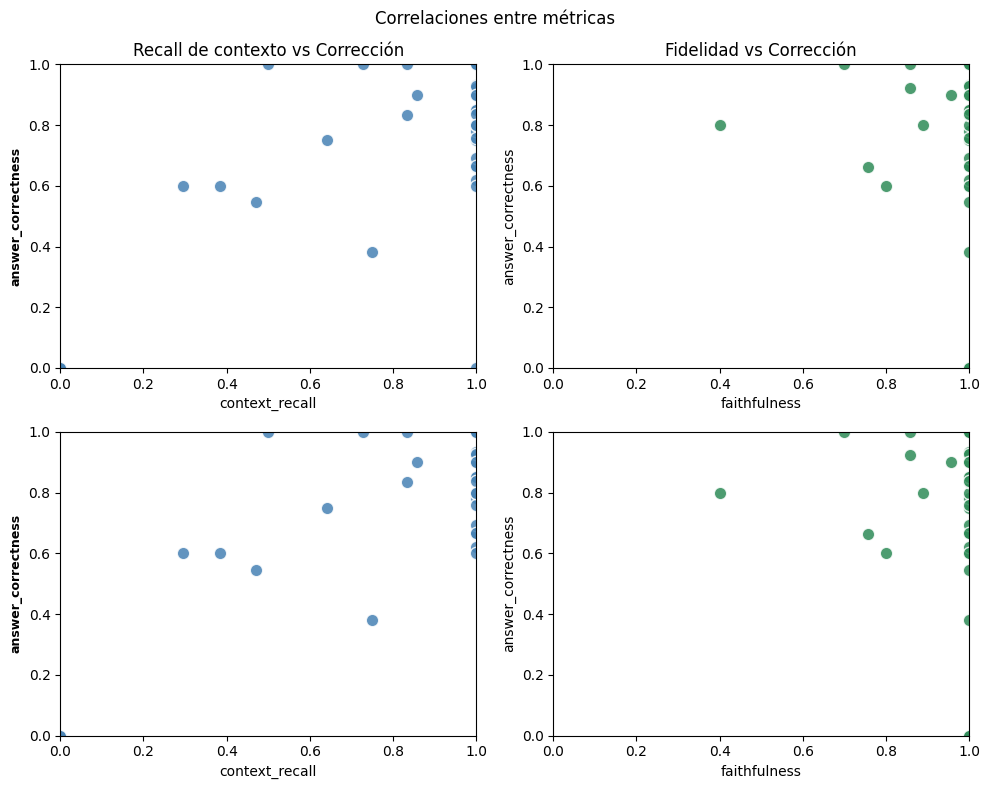

In [19]:
datasets = [
    (df,        f'Todas las preguntas ({len(df)} casos)'),
    (df_limpio, f'Solo búsqueda ({len(df_limpio)} casos)'),
]

scatter_cfg = [
    ('context_recall', 'answer_correctness', 'steelblue',  'Recall de contexto vs Corrección'),
    ('faithfulness',   'answer_correctness', 'seagreen',   'Fidelidad vs Corrección'),
]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for row, (dataset, titulo) in enumerate(datasets):
    axes[row, 0].set_ylabel(titulo, fontsize=9, fontweight='bold')

    for col, (x_metric, y_metric, color, subtitulo) in enumerate(scatter_cfg):
        ax = axes[row, col]
        ax.scatter(dataset[x_metric], dataset[y_metric],
                   color=color, edgecolors='white', s=80, alpha=0.85)
        ax.set_xlabel(x_metric)
        ax.set_ylabel(y_metric)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        if row == 0:
            ax.set_title(subtitulo)

plt.suptitle('Correlaciones entre métricas', fontsize=12)
plt.tight_layout()
plt.show()

In [23]:
import pandas as pd

# ── 1. Cargar el CSV con los tipos de pregunta ──────────────────────────────
df_tipos = pd.read_csv('../data/benchmark_data_typed.csv', sep=';')[['question', 'question_type']]

# ── 2. Cruzar con el dataframe de respuestas (merge por 'question') ─────────
df_merged = df.merge(df_tipos, on='question', how='left')

# Avisar si alguna pregunta no encontró su tipo
sin_tipo = df_merged['question_type'].isna().sum()
if sin_tipo:
    print(f"⚠ {sin_tipo} preguntas sin tipo asignado:")
    print(df_merged[df_merged['question_type'].isna()]['question'].tolist())

# ── 3. Métricas por tipo de pregunta ────────────────────────────────────────
metricas = ['context_recall', 'faithfulness', 'answer_correctness',
            'latency', 'num_tools', 'is_tool_correct']

# Solo las métricas que existan en el dataframe
metricas_disponibles = [m for m in metricas if m in df_merged.columns]

resumen = (
    df_merged
    .groupby('question_type')[metricas_disponibles]
    .agg(['mean', 'count'])
)

# Aplanar MultiIndex de columnas: (metrica, stat) → metrica_stat
resumen.columns = ['_'.join(col) for col in resumen.columns]

# Columna de conteo (igual para todas las métricas, tomamos la primera)
primera_metrica = metricas_disponibles[0]
resumen.insert(0, 'n_preguntas', resumen[f'{primera_metrica}_count'].astype(int))

# Quedarse solo con las medias (en %) y el conteo
cols_mean = [c for c in resumen.columns if c.endswith('_mean')]
resumen_final = resumen[['n_preguntas'] + cols_mean].copy()
resumen_final.columns = ['n_preguntas'] + [c.replace('_mean', '') for c in cols_mean]

# Métricas RAG en porcentaje, latencia y num_tools tal cual
cols_pct = [m for m in ['context_recall', 'faithfulness', 'answer_correctness', 'is_tool_correct']
            if m in resumen_final.columns]
resumen_final[cols_pct] = (resumen_final[cols_pct] * 100).round(2)

cols_raw = [m for m in ['latency', 'num_tools'] if m in resumen_final.columns]
resumen_final[cols_raw] = resumen_final[cols_raw].round(3)

# ── 4. Mostrar ───────────────────────────────────────────────────────────────
print("=" * 80)
print("MÉTRICAS POR TIPO DE PREGUNTA")
print("=" * 80)
print(resumen_final.sort_values('n_preguntas', ascending=False).to_string())

MÉTRICAS POR TIPO DE PREGUNTA
                       n_preguntas  context_recall  faithfulness  answer_correctness  latency  num_tools  is_tool_correct
question_type                                                                                                            
consulta_semantica              15          95.960        98.670              83.010   45.992      1.000           93.330
interaccion_alcance              7         100.000        94.330              95.090    3.144      1.000          100.000
recuperacion_directa             6          87.470        99.290              78.290   42.595      1.167           83.330
datos_faltantes                  6          33.330       100.000              12.500   46.765      1.000           83.330
filtrado_estructurado            5          85.880        95.150              78.600   34.240      1.000           60.000
consulta_predefinida             4          86.760       100.000              80.300   30.770      1.000          10